In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv #standard library, lets us read the CSV data files
from pathlib import Path #builds file paths that work from any folder
from scipy.optimize import minimize #used to optimise the pacing strategy

In [2]:
#World Constants
g = 9.81 #gravity (m/s^2)
a_density = 1.225 #air density (kg/m^3)
dt = 1.0 #time step (seconds)
wind_map = {"low" : 0.5, "medium" : 1.0, "high" : 2.0} #wind exposure label -> effective headwind (m/s)

In [3]:
# Rider Parameters - loaded from data/rider_profiles.csv
rider = "male_tt" #pick the rider: baseline, male_tt, female_tt, male_climber, female_climber

def load_rider(profile_id):
    """Return one rider profile's parameters from data/rider_profiles.csv as a dict."""
    for base in [Path.cwd(), *Path.cwd().parents]: #start here and walk up toward the drive root
        if (base / "data" / "rider_profiles.csv").is_file(): #stop once we find the data folder
            data_dir = base / "data"
            break
    else: #ran out of folders without finding it
        raise FileNotFoundError("Could not find data/rider_profiles.csv - open this notebook from inside the repo.")
    with open(data_dir / "rider_profiles.csv", newline="") as f: #open the profiles file
        for row in csv.DictReader(f): #DictReader keys each row by the CSV header names
            if row["profile_id"] == profile_id: #match the chosen rider
                return row #hand back that rider's parameters
    raise ValueError(f"Rider profile '{profile_id}' is not in rider_profiles.csv") #no match - fail loudly

_r = load_rider(rider) #look up the chosen rider
m = float(_r["mass_kg"]) #total rider + bike mass (kg)
CdA = float(_r["cda_m2"]) #drag area (m^2)
P_max = float(_r["p_max_w"]) #short-duration maximal power ceiling (W)
P_threshold = float(_r["p_threshold_w"]) #power above which fatigue builds (W)
P_base = float(_r["p_base_w"]) #flat-ground sustainable power (W)

# Shared model constants - same for every rider
Crr = 0.004 #rolling resistance coefficient
v_max = 30 #descent speed cap (m/s)
hill_factor = 800 #default gradient-to-power sensitivity (the optimiser tunes this below)
fatigue_rate = 0.05 #how fast fatigue builds above threshold
recovery_rate = 0.01 #how fast fatigue recovers below threshold
fatigue_impact = 0.4 #how much accumulated fatigue lowers the power ceiling

In [4]:
# Course - loaded from data/courses/, repeated for the number of laps
course_file = "tokyo_olympic_tt.csv" #tokyo_olympic_tt.csv, flanders_world_tt.csv, or custom_5km_loop.csv
laps = 2 #Tokyo: women ride 1 lap, men ride 2. Flanders and the custom loop are 1.

def load_course(filename):
    """Return one lap of a course from data/courses/ as a list of (name, distance, grade, turn, wind) tuples."""
    for base in [Path.cwd(), *Path.cwd().parents]: #start here and walk up toward the drive root
        courses_dir = base / "data" / "courses" #the folder the course CSVs live in
        if courses_dir.is_dir(): #stop once we find it
            break
    else: #ran out of folders without finding it
        raise FileNotFoundError("Could not find data/courses - open this notebook from inside the repo.")
    lap = [] #one tuple per segment
    with open(courses_dir / filename, newline="") as f: #open the chosen course file
        for row in csv.DictReader(f): #DictReader keys each row by the CSV header names
            lap.append((row["name"], float(row["distance_m"]), float(row["grade_pct"]),
                        float(row["turn_penalty_s"]), row["wind_exposure"]))
    return lap

lap = load_course(course_file) #one lap of the chosen course
course = [] #the full course = the lap repeated `laps` times
for i in range(laps): #stitch the laps together end to end
    for name, d, gr, turn, wind in lap:
        course.append((name + f" (lap {i+1})", d, gr, turn, wind))

In [5]:
def simulate(params, return_full=False):
    """Run the time-stepping model for a pacing strategy and return the finishing time.

    params is (hill_factor, flat_boost): how hard the rider pushes per unit of gradient,
    and how much above P_base they hold on the flats and descents. With return_full=True
    it also returns the logged arrays for plotting. The optimiser calls this many times,
    so by default it returns only the time.
    """
    hill_factor, flat_boost = params
    v = 0.0 #starting speed
    distance = 0.0 #starting distance
    t = 0 #starting time
    fatigue = 0 #starting fatigue
    times = []; speeds = []; distances = []; drags = []; powers = []; fatigues = []; gradients = []
    for name, segment_distance, grade_percent, turn_penalty, wind_exposure in course:
        grad = np.arctan(grade_percent / 100) #percent grade to radians
        hw = wind_map[wind_exposure] #wind label to m/s
        t += turn_penalty #fixed cornering time cost for this segment
        segment_start = distance
        while distance - segment_start < segment_distance:
            if grad > 0.01: #climbing: push harder the steeper it gets
                P_target = max(50, P_base + hill_factor * grad)
            else: #flat or descending: hold P_base plus the flat boost
                P_target = max(50, P_base + flat_boost)
            P_cap = P_max * (1 - fatigue_impact * fatigue) #fatigue lowers the ceiling
            P_output = min(P_target, P_cap) #actual power applied
            if P_output > P_threshold: #above threshold -> fatigue builds (squared overshoot)
                fatigue = min(fatigue + fatigue_rate * (((P_output - P_threshold) / P_threshold)**2 * dt), 1.0)
            else: #below threshold -> recover
                fatigue = max(0, fatigue - recovery_rate * dt)
            Rider_force = P_output / max(v, 0.50) #force = power / speed (floored to avoid divide-by-zero)
            drag = 0.5 * a_density * CdA * ((v + hw)**2) #aerodynamic drag
            gravity = m * g * np.sin(grad) #gravity along the slope
            rolling = Crr * m * g * np.cos(grad) #rolling resistance
            net = Rider_force - drag - gravity - rolling #net force
            v = max(0, min(v + ((dt / m) * net), v_max)) #integrate speed, clamp to [0, v_max]
            distance += v * dt #advance distance
            t += dt #advance time
            times.append(t); speeds.append(v); distances.append(distance)
            drags.append(drag); powers.append(P_output); fatigues.append(fatigue); gradients.append(grade_percent)
    if return_full:
        return t, fatigue, times, speeds, distances, drags, powers, fatigues, gradients
    return t

In [6]:
# Optimise the pacing strategy (hill_factor, flat_boost) to minimise total time for this rider on this course
result = minimize(simulate, x0=[800, 50], method="Nelder-Mead", bounds=[(0, 2000), (0, 150)]) #derivative-free search
best_hill_factor, best_flat_boost = result.x #the time-minimising pacing
best_time = result.fun #its finishing time (seconds)
baseline_time = simulate((800, 0)) #the un-tuned reactive pacing, for comparison

print("Rider: " + rider + "   Course: " + course_file.replace(".csv", "") + "   Laps: " + str(laps))
print("Optimal hill_factor : " + str(round(best_hill_factor, 1)))
print("Optimal flat_boost  : " + str(round(best_flat_boost, 1)))
print("Baseline time : " + str(round(baseline_time / 60, 1)) + " min  " + str(round(baseline_time % 60)) + " sec")
print("Optimal time  : " + str(round(best_time / 60, 1)) + " min  " + str(round(best_time % 60)) + " sec")
print("Time saved    : " + str(round(baseline_time - best_time, 1)) + " sec")

Rider: male_tt   Course: tokyo_olympic_tt   Laps: 2
Optimal hill_factor : 1748.1
Optimal flat_boost  : 69.0
Baseline time : 62.1 min  7 sec
Optimal time  : 59.4 min  23 sec
Time saved    : 164.0 sec


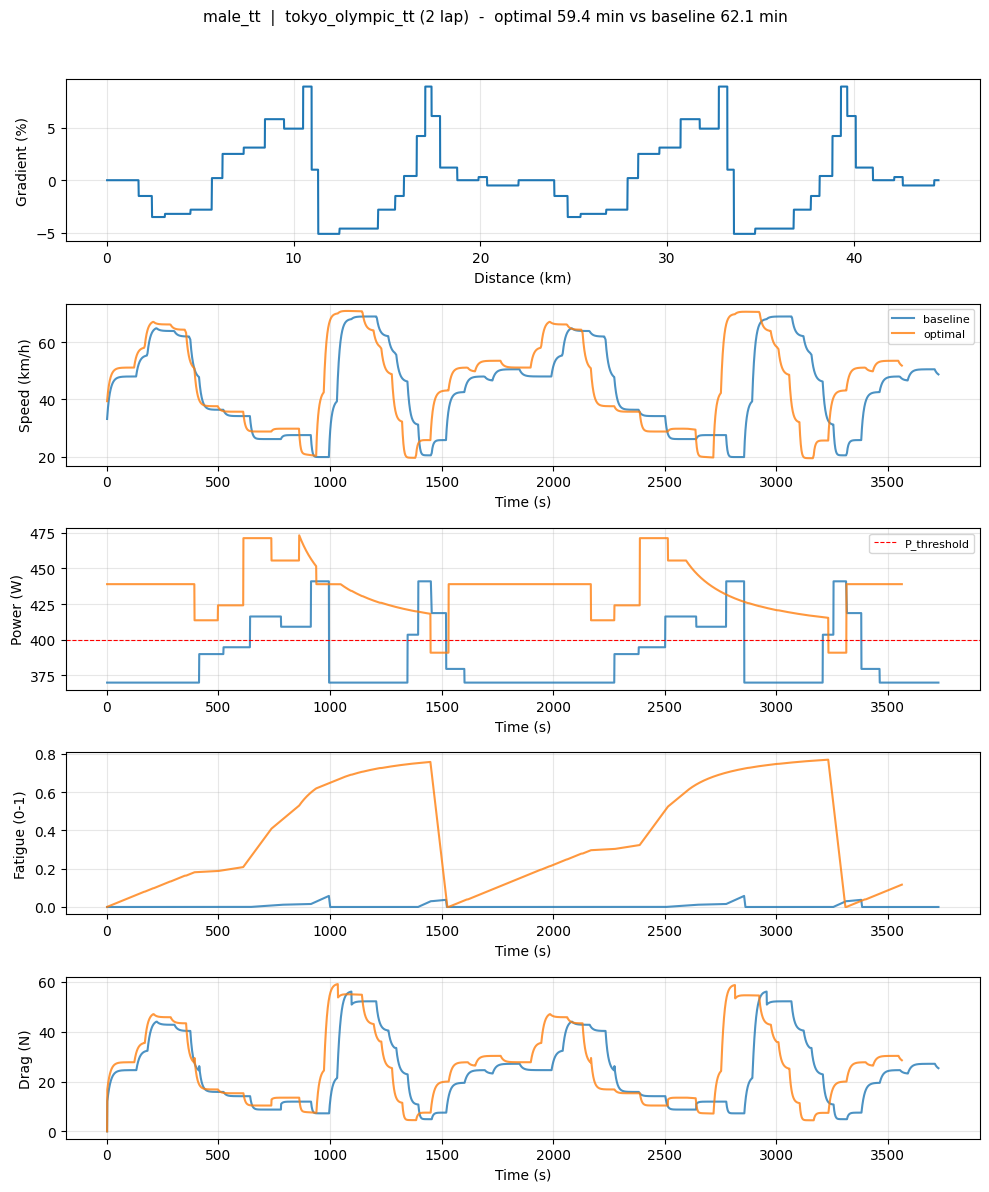

In [7]:
# Compare the optimal pacing against the un-tuned baseline
t_opt,  fat_opt,  times_opt,  speeds_opt,  distances_opt,  drags_opt,  powers_opt,  fatigues_opt,  gradients_opt  = simulate((best_hill_factor, best_flat_boost), return_full=True)
t_base, fat_base, times_base, speeds_base, distances_base, drags_base, powers_base, fatigues_base, gradients_base = simulate((800, 0), return_full=True)

fig, ax = plt.subplots(5, 1, figsize=(10, 12))
fig.suptitle(rider + "  |  " + course_file.replace(".csv", "") + " (" + str(laps) + " lap)  -  optimal " + str(round(best_time / 60, 1)) + " min vs baseline " + str(round(baseline_time / 60, 1)) + " min", fontsize=11, y=0.99)

ax[0].plot([d / 1000 for d in distances_base], gradients_base) #gradient profile (one line - it is the course)
ax[0].set_ylabel("Gradient (%)"); ax[0].set_xlabel("Distance (km)"); ax[0].grid(alpha=0.3)

ax[1].plot(times_base, [s * 3.6 for s in speeds_base], label="baseline", alpha=0.8)
ax[1].plot(times_opt,  [s * 3.6 for s in speeds_opt],  label="optimal",  alpha=0.8)
ax[1].set_ylabel("Speed (km/h)"); ax[1].set_xlabel("Time (s)"); ax[1].grid(alpha=0.3); ax[1].legend(loc="upper right", fontsize=8)

ax[2].plot(times_base, powers_base, alpha=0.8)
ax[2].plot(times_opt,  powers_opt,  alpha=0.8)
ax[2].axhline(P_threshold, color="red", linestyle="--", linewidth=0.8, label="P_threshold")
ax[2].set_ylabel("Power (W)"); ax[2].set_xlabel("Time (s)"); ax[2].grid(alpha=0.3); ax[2].legend(loc="upper right", fontsize=8)

ax[3].plot(times_base, fatigues_base, alpha=0.8)
ax[3].plot(times_opt,  fatigues_opt,  alpha=0.8)
ax[3].set_ylabel("Fatigue (0-1)"); ax[3].set_xlabel("Time (s)"); ax[3].grid(alpha=0.3)

ax[4].plot(times_base, drags_base, alpha=0.8)
ax[4].plot(times_opt,  drags_opt,  alpha=0.8)
ax[4].set_ylabel("Drag (N)"); ax[4].set_xlabel("Time (s)"); ax[4].grid(alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()